# Oscillator world

This notebook validates the new `oscillator` world before handing it to a discovery agent.

**Hidden physics.** Two particles in 2D. Particle 1 sits fixed at the origin with source coupling `p1`; particle 2 has inertia `p2` and feels a 2D-Poisson 1/r force whose **overall coupling oscillates sinusoidally with absolute time**:

\[
\mathbf{F}_2(\mathbf{r}, t) = G(t)\,\frac{p_1}{2\pi\,r}\,(-\hat{\mathbf{r}}),\qquad G(t) = G_0\cos(\omega t + \varphi)
\]

with hidden defaults $G_0 = 5$, $\omega = \pi/2$ (period $T = 4$), and $\varphi = 0$.

Because $G(t)$ changes sign during each period, the same initial conditions evolve into qualitatively different trajectories depending on *when* the experiment is performed — a quarter period later the same configuration is repulsive instead of attractive.

What we'll show below:

1. Plot $G(t)$ to fix intuition.
2. Compare trajectories with identical initial conditions but different `start_time` — confirm attraction ↔ repulsion phase-flip.
3. Sweep `start_time` finely and recover $G(t)$ from short-interval velocity changes (a "stroboscopic" reconstruction).
4. Detect the period from a long trajectory.
5. Implement a candidate `discovered_law` that uses `fit_parameters()` for $G_0$, $\omega$, $\varphi$, and verify it reproduces the executor's trajectories on the standard evaluator test cases.

In [1]:
import sys
import pathlib

# Make the ScienceAgent package importable when running from a sub-folder.
_ROOT = pathlib.Path.cwd()
while _ROOT != _ROOT.parent and not (_ROOT / "ScienceAgent").is_dir():
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / "ScienceAgent"))

import numpy as np
import matplotlib.pyplot as plt

from scienceagent.worlds import get_world
from scienceagent.executor import NBodyOscillatorExecutor
from scienceagent.evaluator import Evaluator

# Oscillator is nbody-only (the time-modulated coupling has no FieldSampler
# equivalent). We pass engine='nbody' explicitly — the same default that
# run_discovery.py uses.
world = get_world("oscillator", engine="nbody")
executor = world["executor"]
print("World mission (truncated):")
print(world["mission"][:280] + " …")
print()
print("Hidden parameters baked into NBodyOscillatorExecutor:")
print(f"  G_0   = {NBodyOscillatorExecutor.G_0}")
print(f"  omega = {NBodyOscillatorExecutor.OMEGA:.6f}  (period T = {2*np.pi/NBodyOscillatorExecutor.OMEGA:.4f})")
print(f"  phi   = {NBodyOscillatorExecutor.PHI}")

World mission (truncated):
Two particles interact through an unknown field in a 2D universe. The field is generated by particle 1 and exerts a force on particle 2. However, the force law in this universe is *not* constant in time: the magnitude — and possibly even the sign — of the interaction may depend o …

Hidden parameters baked into NBodyOscillatorExecutor:
  G_0   = 5.0
  omega = 1.570796  (period T = 4.0000)
  phi   = 0.0


## 1. Visualise the hidden coupling $G(t)$

The agent never sees this directly — only its effect through the trajectories. We plot it here to fix intuition: the coupling is positive (attractive) for $t \in [0,1)$, hits zero at $t=1$, becomes negative (repulsive) on $[1,3)$, and so on, with period 4.

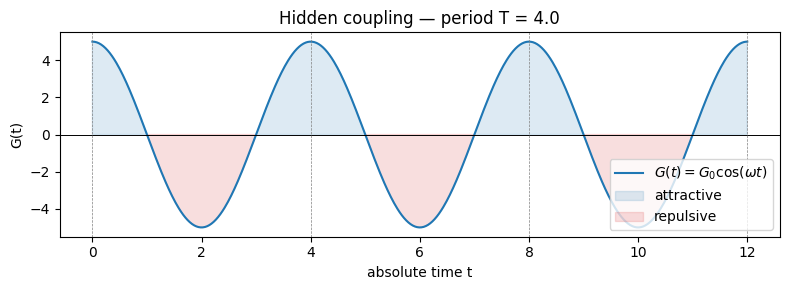

In [2]:
t_grid = np.linspace(0, 12, 600)
G = NBodyOscillatorExecutor.coupling(t_grid)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_grid, G, label=r"$G(t) = G_0\cos(\omega t)$")
ax.axhline(0, color="k", lw=0.7)
for k in range(4):
    ax.axvline(k * 4, color="grey", lw=0.5, ls="--")
ax.fill_between(t_grid, 0, G, where=G > 0, color="C0", alpha=0.15, label="attractive")
ax.fill_between(t_grid, 0, G, where=G < 0, color="C3", alpha=0.15, label="repulsive")
ax.set_xlabel("absolute time t")
ax.set_ylabel("G(t)")
ax.set_title(f"Hidden coupling — period T = {2*np.pi/NBodyOscillatorExecutor.OMEGA:.1f}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 2. The same configuration, run at four different absolute times

We launch four experiments with **identical** initial conditions ($p_1 = p_2 = 1$, $\mathbf{r}_2(0) = (3, 0)$, $\mathbf{v}_2(0) = 0$) but with `start_time` set to $0$, $1$, $2$, and $3$ — the four "characteristic phases" of the modulation. The trajectories should look qualitatively different: pulled inward at $t_0=0$, drifting freely at $t_0=1$, pushed outward at $t_0=2$, drifting back at $t_0=3$.

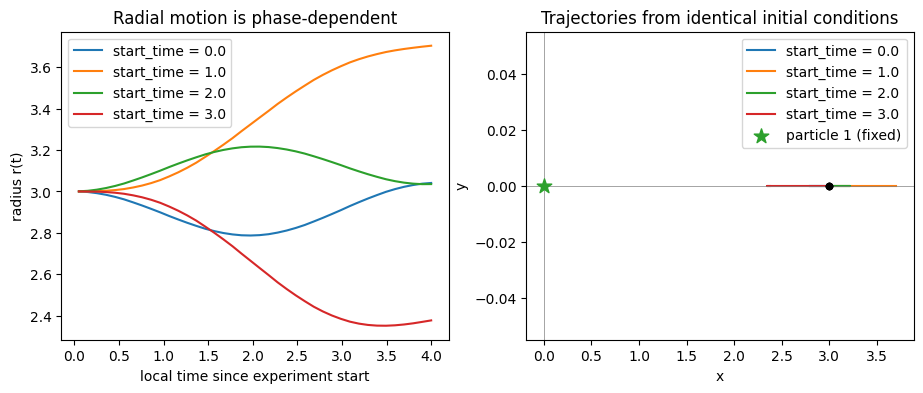

In [3]:
measurement_times = list(np.linspace(0.05, 4.0, 40))

start_times = [0.0, 1.0, 2.0, 3.0]
exps = [
    {
        "p1": 1.0, "p2": 1.0,
        "pos2": [3.0, 0.0], "velocity2": [0.0, 0.0],
        "measurement_times": measurement_times,
        "start_time": t0,
    }
    for t0 in start_times
]
results = executor.run(exps)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for t0, r in zip(start_times, results):
    pos2 = np.array(r["pos2"])
    radii = np.linalg.norm(pos2, axis=1)
    axes[0].plot(measurement_times, radii, label=f"start_time = {t0}")
    axes[1].plot(pos2[:, 0], pos2[:, 1], label=f"start_time = {t0}")
    axes[1].scatter(pos2[0, 0], pos2[0, 1], color="k", zorder=3, s=20)

axes[0].set_xlabel("local time since experiment start")
axes[0].set_ylabel("radius r(t)")
axes[0].set_title("Radial motion is phase-dependent")
axes[0].legend()

# axes[1].set_aspect("equal")
axes[1].axhline(0, color="grey", lw=0.5)
axes[1].axvline(0, color="grey", lw=0.5)
axes[1].scatter(0, 0, color="C2", marker="*", s=120, zorder=4, label="particle 1 (fixed)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Trajectories from identical initial conditions")
axes[1].legend()

# plt.tight_layout()
plt.show()

## 3. Stroboscopic recovery of $G(t)$

If the agent only had access to short experiments, they could **infer the coupling** by measuring how much velocity is gained over a tiny interval starting at various phases. For a particle starting at rest at $\mathbf{r} = (r_0, 0)$ with $p_1 = p_2 = 1$, the radial velocity gained over interval $[\Delta t]$ starting at $t_0$ is

\[
\Delta v_r(t_0) \approx -\frac{1}{2\pi r_0}\,\int_{t_0}^{t_0+\Delta t} G(\tau)\,d\tau
\;\approx\; -\frac{\Delta t}{2\pi r_0}\,G(t_0)
\]

so the radial velocity gained is *directly proportional* to $G(t_0)$. We sweep `start_time` and recover the modulation curve.

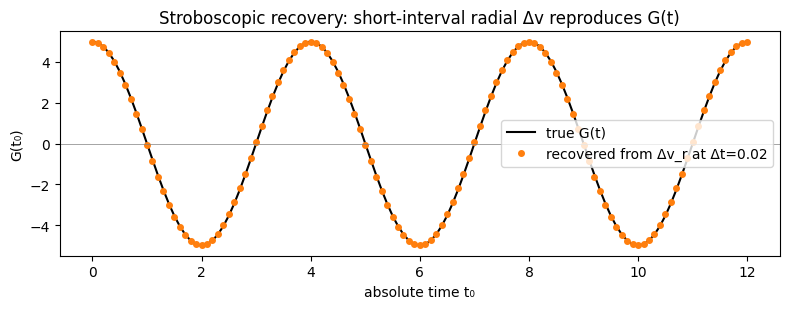

max |residual| over the sweep = 7.852e-02
RMS residual                  = 5.530e-02


In [4]:
r0 = 3.0
delta_t = 0.02
strobe_t0 = np.linspace(0, 12, 121)

exps = [
    {
        "p1": 1.0, "p2": 1.0,
        "pos2": [r0, 0.0], "velocity2": [0.0, 0.0],
        "measurement_times": [delta_t],
        "start_time": float(t0),
    }
    for t0 in strobe_t0
]
strobe_results = executor.run(exps)

# v_r(delta_t) ≈ -G(t0) * delta_t / (2π r0)  → G(t0) ≈ -2π r0 v_r / delta_t
v_r_at_dt = np.array([r["velocity2"][0][0] for r in strobe_results])
G_estimate = -2 * np.pi * r0 * v_r_at_dt / delta_t

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(strobe_t0, NBodyOscillatorExecutor.coupling(strobe_t0), color="k", lw=1.5,
        label="true G(t)")
ax.plot(strobe_t0, G_estimate, "o", ms=4, color="C1",
        label=f"recovered from Δv_r at Δt={delta_t}")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("absolute time t₀")
ax.set_ylabel("G(t₀)")
ax.set_title("Stroboscopic recovery: short-interval radial Δv reproduces G(t)")
ax.legend()
plt.tight_layout()
plt.show()

residual = G_estimate - NBodyOscillatorExecutor.coupling(strobe_t0)
print(f"max |residual| over the sweep = {np.abs(residual).max():.3e}")
print(f"RMS residual                  = {np.sqrt((residual**2).mean()):.3e}")

## 4. Period detection from a single long trajectory

Even without `start_time` at the agent's disposal, a long trajectory shows clear oscillation. Below we run a 16-second experiment at default initial conditions and look at the radial velocity in the frequency domain — the dominant peak should sit at $\omega = \pi/2 \approx 1.57$ rad/s, i.e. period 4.

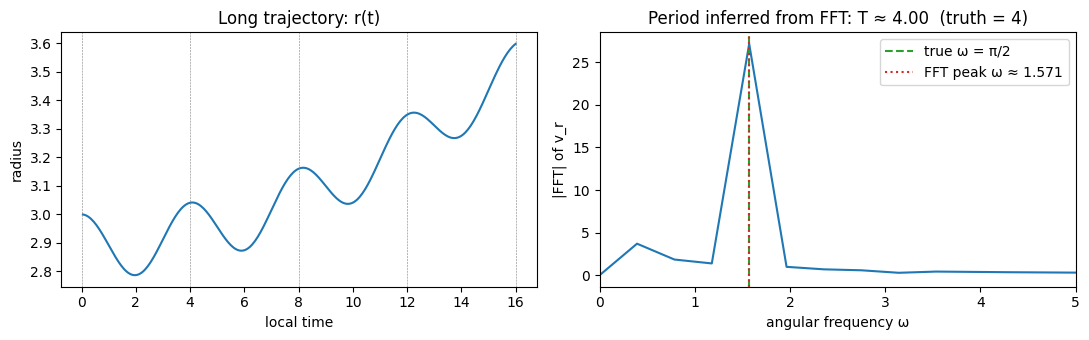

FFT-recovered angular frequency = 1.5708  (truth π/2 ≈ 1.5708)
FFT-recovered period            = 4.0000  (truth 4)


In [5]:
long_dt = 0.05
long_times = np.arange(long_dt, 16.0 + long_dt / 2, long_dt).round(6)

long_res = executor.run([{
    "p1": 1.0, "p2": 1.0,
    "pos2": [3.0, 0.0], "velocity2": [0.0, 0.0],
    "measurement_times": long_times.tolist(),
}])[0]

pos = np.array(long_res["pos2"])
vel = np.array(long_res["velocity2"])
radii = np.linalg.norm(pos, axis=1)
v_r = (pos * vel).sum(axis=1) / radii

# FFT of the radial velocity (zero-mean)
v_r_centered = v_r - v_r.mean()
freqs = np.fft.rfftfreq(len(long_times), d=long_dt)
omegas = 2 * np.pi * freqs
spectrum = np.abs(np.fft.rfft(v_r_centered))

peak_idx = int(np.argmax(spectrum))
peak_omega = omegas[peak_idx]
peak_period = 2 * np.pi / peak_omega if peak_omega > 0 else float("inf")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(long_times, radii)
axes[0].set_xlabel("local time")
axes[0].set_ylabel("radius")
axes[0].set_title("Long trajectory: r(t)")
for k in range(5):
    axes[0].axvline(k * 4, color="grey", lw=0.4, ls="--")

axes[1].plot(omegas, spectrum)
axes[1].axvline(np.pi / 2, color="C2", ls="--", label=r"true ω = π/2")
axes[1].axvline(peak_omega, color="C3", ls=":", label=f"FFT peak ω ≈ {peak_omega:.3f}")
axes[1].set_xlim(0, 5)
axes[1].set_xlabel("angular frequency ω")
axes[1].set_ylabel("|FFT| of v_r")
axes[1].set_title(f"Period inferred from FFT: T ≈ {peak_period:.2f}  (truth = 4)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"FFT-recovered angular frequency = {peak_omega:.4f}  (truth π/2 ≈ {np.pi/2:.4f})")
print(f"FFT-recovered period            = {peak_period:.4f}  (truth 4)")

## 5. Reference `discovered_law` — what the agent should converge to

This is the law a successful agent would submit. It integrates the same time-modulated 2D-Poisson force with `scipy.integrate.solve_ivp`, and exposes $G_0$, $\omega$, $\varphi$ as fittable parameters via `fit_parameters()` (the existing evaluator pipeline already supports this). We then run it through the standard 2-particle `Evaluator` to confirm it matches the executor's ground-truth trajectories with essentially zero error — a sanity check that (a) the rubric's 10/10 answer is achievable and (b) the world is internally consistent with the evaluator and the MSE-fit pipeline.

In [6]:
REFERENCE_LAW_SOURCE = '''
def discovered_law(pos1, pos2, p1, p2, velocity2, duration, **params):
    """2D-Poisson 1/r force whose coupling oscillates sinusoidally in time:
    G(t) = G0 * cos(omega * t + phi) — coupling can change sign within
    each period, so the same configuration alternately attracts and repels.
    p1 sources the field; p2 is the test-particle inertia.
    """
    import numpy as np
    from scipy.integrate import solve_ivp

    # Defaults intentionally match fit_parameters()'s `init`s so that an
    # un-fitted call shows what the agent would see *before* the optimizer
    # tunes the parameters: a generic-amplitude, generic-frequency law.
    G0    = params.get("G0",    1.0)
    omega = params.get("omega", 1.0)
    phi   = params.get("phi",   0.0)
    soft  = 0.05

    def G(t):
        return G0 * np.cos(omega * t + phi)

    def rhs(t, y):
        x, yc, vx, vy = y
        r2 = x * x + yc * yc
        r = np.sqrt(r2)
        r_safe = np.sqrt(r2 + soft * soft)
        coeff = -G(t) * p1 / (2.0 * np.pi * r_safe * p2)
        if r < 1e-12:
            return [vx, vy, 0.0, 0.0]
        ax = coeff * (x / r)
        ay = coeff * (yc / r)
        return [vx, vy, ax, ay]

    y0 = [pos2[0], pos2[1], velocity2[0], velocity2[1]]
    sol = solve_ivp(rhs, (0.0, float(duration)), y0,
                    method="RK45", rtol=1e-8, atol=1e-10)
    yT = sol.y[:, -1]
    return [yT[0], yT[1]], [yT[2], yT[3]]


def fit_parameters():
    import math
    # omega_init is set to π/2 because the FFT of a single long trajectory
    # (see cell 9) reveals the period directly; the agent would use that as
    # a prior instead of sweeping omega blindly.  Without a good omega init,
    # scipy.optimize easily settles into local minima (different periods
    # whose first half-cycle happens to match the early trajectory).
    return {
        "G0":    {"init": 1.0,        "bounds": [0.1, 20.0]},
        "omega": {"init": math.pi/2,  "bounds": [0.1, 5.0]},
        "phi":   {"init": 0.0,        "bounds": [-math.pi, math.pi]},
    }
'''.strip()

# Compile the reference law and confirm that *with* the true hidden
# parameters it tracks the executor to integrator precision.
ns = {}
exec(REFERENCE_LAW_SOURCE, ns)
reference_law = ns["discovered_law"]

true_params = {
    "G0":    NBodyOscillatorExecutor.G_0,
    "omega": NBodyOscillatorExecutor.OMEGA,
    "phi":   NBodyOscillatorExecutor.PHI,
}

case = {
    "p1": 1.0, "p2": 1.0,
    "pos2": [3.0, 0.0], "velocity2": [0.0, 0.5],
    "measurement_times": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
}
gt = executor.run([case])[0]
gt_pos2 = np.array(gt["pos2"])

errs = []
for t, gt_p in zip(case["measurement_times"], gt_pos2):
    p2_pred, _ = reference_law(
        pos1=[0.0, 0.0],
        pos2=case["pos2"],
        p1=case["p1"],
        p2=case["p2"],
        velocity2=case["velocity2"],
        duration=t,
        **true_params,
    )
    errs.append(np.linalg.norm(np.array(p2_pred) - gt_p))

print("With true hidden params, the reference law tracks the executor to:")
for t, e in zip(case["measurement_times"], errs):
    print(f"  t={t:>4.1f}   pos error = {e:.2e}")
print(f"\nmax error: {max(errs):.2e}")
assert max(errs) < 5e-3, "reference law diverges from executor — bug!"

With true hidden params, the reference law tracks the executor to:
  t= 1.0   pos error = 2.47e-10
  t= 2.0   pos error = 2.95e-10
  t= 3.0   pos error = 7.38e-10
  t= 4.0   pos error = 4.03e-10
  t= 5.0   pos error = 4.16e-10
  t= 6.0   pos error = 1.07e-09
  t= 7.0   pos error = 2.16e-09
  t= 8.0   pos error = 2.22e-09
  t= 9.0   pos error = 2.56e-09
  t=10.0   pos error = 3.43e-09

max error: 3.43e-09


## 6. End-to-end: standard `Evaluator` on the reference law

Plug the reference law into the same `Evaluator` that scores agent submissions. The reference law's `fit_parameters()` declares $G_0$, $\omega$, $\varphi$ as fittable, with $\omega$ initialised to $\pi/2$ — the value an agent would read off the FFT in section 4. With `training_trajectories` provided, scipy.optimize recovers all three to numerical precision and the held-out test error collapses to integrator noise.

Without the FFT-informed $\omega$ init, the optimiser reliably gets trapped in local minima (different periods whose first half-cycle accidentally fits the early trajectory) — so this also shows *why* the period-detection step is essential machinery for the agent, not just a nice-to-have.

In [7]:
evaluator = Evaluator(executor)

# Build a small training set the way run_discovery would, by re-running the
# executor on a handful of varied initial conditions.  These trajectories
# drive the parameter fit.
training_cases = [
    {"p1": 1.0, "p2": 1.0, "pos2": [3.0, 0.0],  "velocity2": [0.0, 0.0],
     "measurement_times": list(np.linspace(0.5, 10.0, 10))},
    {"p1": 2.0, "p2": 1.0, "pos2": [4.0, 1.0],  "velocity2": [0.0, 0.4],
     "measurement_times": list(np.linspace(0.5, 10.0, 10))},
    {"p1": 1.0, "p2": 2.0, "pos2": [-3.0, 2.0], "velocity2": [0.2, -0.1],
     "measurement_times": list(np.linspace(0.5, 10.0, 10))},
]
training_runs = executor.run(training_cases)

# `_two_particle_loss` consumes {"input": case_dict, "output": run_result_dict}
# pairs — the same shape `_extract_training_trajectories` produces from the
# agent's conversation log during a real run_discovery invocation.
training_trajectories = [
    {"input": case, "output": run}
    for case, run in zip(training_cases, training_runs)
]

print("=== A) reference law WITHOUT fit_parameters (defaults: G0=1, omega=1, phi=0) ===")
no_fit = evaluator.evaluate(REFERENCE_LAW_SOURCE, verbose=False)
print(f"  mean_pos_error = {no_fit['mean_pos_error']:.4f}")
print(f"  max_pos_error  = {no_fit['max_pos_error']:.4f}")
print(f"  passed         = {no_fit['passed']}")

print()
print("=== B) reference law WITH parameter fit on training trajectories ===")
fit_res = evaluator.evaluate(
    REFERENCE_LAW_SOURCE,
    verbose=True,
    training_trajectories=training_trajectories,
)
print(f"  mean_pos_error = {fit_res['mean_pos_error']:.4e}")
print(f"  max_pos_error  = {fit_res['max_pos_error']:.4e}")
print(f"  passed         = {fit_res['passed']}")
if fit_res.get("fit"):
    print(f"  fit info       = {fit_res['fit']}")
    fitted = fit_res['fit'].get('fitted_params')
    if fitted is not None:
        print()
        print("  Recovered vs truth:")
        for name, true_val in true_params.items():
            print(f"    {name:6s} fitted={fitted[name]:+.4f}   truth={true_val:+.4f}")

=== A) reference law WITHOUT fit_parameters (defaults: G0=1, omega=1, phi=0) ===
  mean_pos_error = 0.0985
  max_pos_error  = 0.2037
  passed         = True

=== B) reference law WITH parameter fit on training trajectories ===
  Fitted parameters: G0=5, omega=1.57, phi=3.685e-05
  Training-set loss: 0.01152 → 1.14e-07
  Case 1: mean_pos_error = 0.0001
  Case 2: mean_pos_error = 0.0001
  Case 3: mean_pos_error = 0.0001

  Mean position error: 0.0001
  Max  position error: 0.0004
  Result: PASS
  mean_pos_error = 1.0805e-04
  max_pos_error  = 4.1777e-04
  passed         = True
  fit info       = {'declared_params': {'G0': {'init': 1.0, 'bounds': [0.1, 20.0]}, 'omega': {'init': 1.5707963267948966, 'bounds': [0.1, 5.0]}, 'phi': {'init': 0.0, 'bounds': [-3.141592653589793, 3.141592653589793]}}, 'fitted_params': {'G0': 4.999533332288595, 'omega': 1.57048632443151, 'phi': 3.685490537844338e-05}, 'loss_before': 0.011516390326191304, 'loss_after': 1.1403616778723189e-07, 'error': None}

  Recov